In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report, 
    confusion_matrix, 
    roc_auc_score, 
    roc_curve, 
    precision_recall_curve
)
import xgboost as xgb
from imblearn.over_sampling import SMOTE
import shap


df = pd.read_csv("../data/processed/model_ready.csv")

c:\Users\conno\anaconda3\Lib\site-packages\pandas\core\computation\expressions.py:22: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.8.7' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
c:\Users\conno\anaconda3\Lib\site-packages\pandas\core\arrays\masked.py:56: UserWarning: Pandas requires version '1.4.2' or newer of 'bottleneck' (version '1.3.7' currently installed).
  from pandas.core import (


## Logistic Regression

In [2]:
# Prepare features and target
target = 'final_four'
features = [
    'barthag',
    'adj_o',
    'adj_d',
    'adj_t',
    'seed_filled',
    'elite_seed',
    'wab',
    'ov_cur_sos'
]

X = df[features]
y = df[target]

In [3]:
# Time-based split - more realistic for tournament prediction
# Train on 2008-2021, Test on 2022-2024
train_mask = df['year'] <= 2021
test_mask = df['year'] >= 2022

X_train = df[train_mask][features]
X_test = df[test_mask][features]
y_train = df[train_mask][target]
y_test = df[test_mask][target]

print("="*50)
print("TIME-BASED TRAIN-TEST SPLIT")
print("="*50)
print(f"\nTraining years: {sorted(df[train_mask]['year'].unique())}")
print(f"Test years: {sorted(df[test_mask]['year'].unique())}")
print(f"\nTraining set size: {len(X_train)}")
print(f"Test set size: {len(X_test)}")
print(f"\nTraining set Final Four teams: {y_train.sum()}")
print(f"Test set Final Four teams: {y_test.sum()}")
print(f"\nClass distribution in training:")
print(y_train.value_counts())
print(f"\nClass distribution in test:")
print(y_test.value_counts())

TIME-BASED TRAIN-TEST SPLIT

Training years: [2008, 2009, 2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2021]
Test years: [2022, 2023, 2024]

Training set size: 4524
Test set size: 1083

Training set Final Four teams: 52
Test set Final Four teams: 12

Class distribution in training:
final_four
0    4472
1      52
Name: count, dtype: int64

Class distribution in test:
final_four
0    1071
1      12
Name: count, dtype: int64


In [4]:
# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Features scaled successfully")
print(f"Training data shape: {X_train_scaled.shape}")
print(f"Test data shape: {X_test_scaled.shape}")

Features scaled successfully
Training data shape: (4524, 8)
Test data shape: (1083, 8)


### SMOTE

* Use for high class imbalance (Final Four Teams vs. Non-Final Four Teams)

SMOTE RESAMPLING

Class distribution BEFORE SMOTE:
final_four
0    4472
1      52
Name: count, dtype: int64

Class distribution AFTER SMOTE:
final_four
0    4472
1     894
Name: count, dtype: int64

Original training set size: 4524
Resampled training set size: 5366


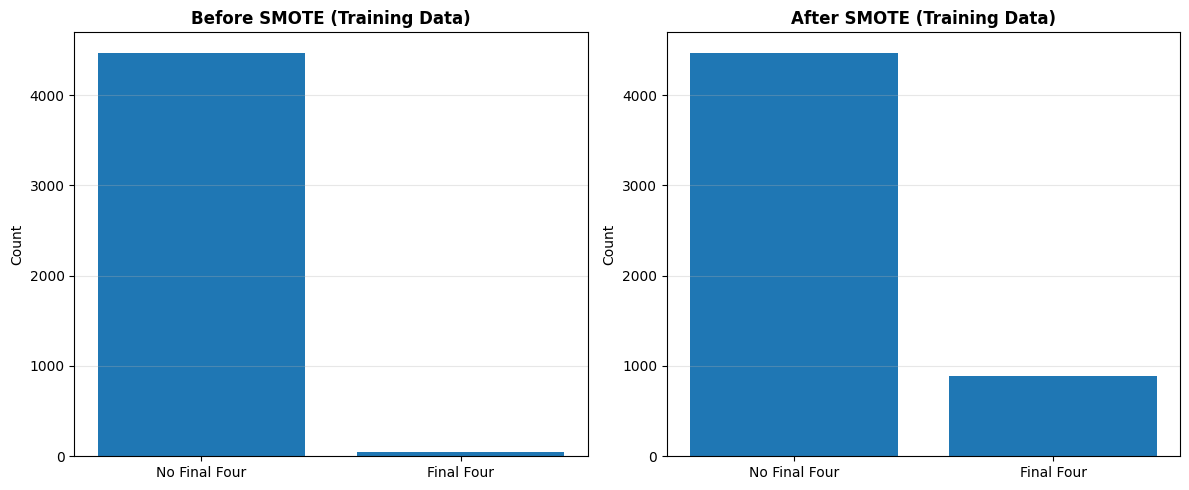

In [5]:
# Apply SMOTE to training data only
smote = SMOTE(random_state=42, sampling_strategy=0.2)  # 20% ratio instead of 1.0 (50-50)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train_scaled, y_train)

print("="*50)
print("SMOTE RESAMPLING")
print("="*50)
print("\nClass distribution BEFORE SMOTE:")
print(y_train.value_counts())
print(f"\nClass distribution AFTER SMOTE:")
print(pd.Series(y_train_resampled).value_counts())
print(f"\nOriginal training set size: {len(X_train)}")
print(f"Resampled training set size: {len(X_train_resampled)}")

# Visualize the effect of SMOTE
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Before SMOTE
axes[0].bar(['No Final Four', 'Final Four'], y_train.value_counts().sort_index())
axes[0].set_title('Before SMOTE (Training Data)', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Count')
axes[0].grid(True, alpha=0.3, axis='y')

# After SMOTE
axes[1].bar(['No Final Four', 'Final Four'], 
            pd.Series(y_train_resampled).value_counts().sort_index())
axes[1].set_title('After SMOTE (Training Data)', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Count')
axes[1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

### Model Training

In [6]:
# Train logistic regression model
log_reg = LogisticRegression(
    random_state=42,
    max_iter=1000,
    class_weight=None  # Using SMOTE instead of class_weight
)

log_reg.fit(X_train_resampled, y_train_resampled)

print(f"Number of iterations: {log_reg.n_iter_[0]}")
print(f"Converged: {log_reg.n_iter_[0] < 1000}")

Number of iterations: 33
Converged: True


In [7]:
# Make predictions on test set (2022-2024)
y_pred = log_reg.predict(X_test_scaled)
y_pred_proba = log_reg.predict_proba(X_test_scaled)[:, 1]

print("="*50)
print("PREDICTIONS ON TEST SET (2022-2024)")
print("="*50)
print(f"Predicted Final Four teams: {y_pred.sum()}")
print(f"Actual Final Four teams: {y_test.sum()}")
print(f"Prediction rate: {y_pred.sum() / len(y_pred):.2%}")
print(f"Actual rate: {y_test.sum() / len(y_test):.2%}")

PREDICTIONS ON TEST SET (2022-2024)
Predicted Final Four teams: 37
Actual Final Four teams: 12
Prediction rate: 3.42%
Actual rate: 1.11%


### Confusion Matrix

CONFUSION MATRIX
[[1041   30]
 [   5    7]]


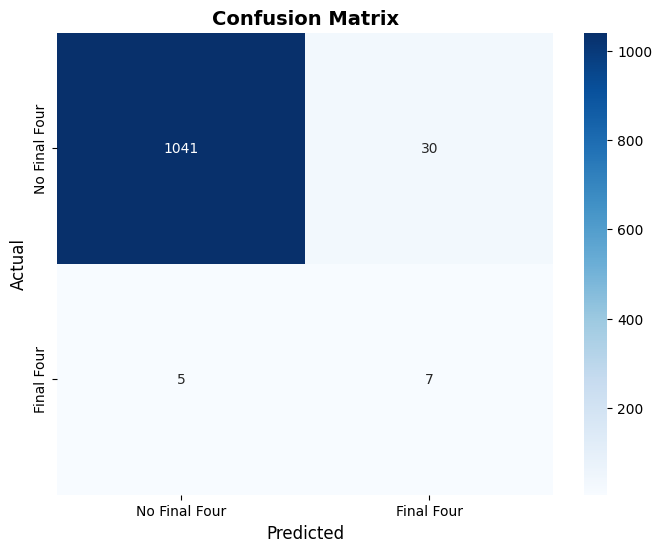

In [8]:
# Confusion Matrix
print("="*50)
print("CONFUSION MATRIX")
print("="*50)

cm = confusion_matrix(y_test, y_pred)
print(cm)

# Visualize
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['No Final Four', 'Final Four'],
            yticklabels=['No Final Four', 'Final Four'])
plt.title('Confusion Matrix', fontsize=14, fontweight='bold')
plt.ylabel('Actual', fontsize=12)
plt.xlabel('Predicted', fontsize=12)
plt.show()

In [9]:
threshold = 0.90
y_pred_adjusted = (y_pred_proba >= threshold).astype(int)

print(f"Predicted Final Four teams: {y_pred_adjusted.sum()}")
print(f"Actual Final Four teams: {y_test.sum()}")

Predicted Final Four teams: 5
Actual Final Four teams: 12


CONFUSION MATRIX (Threshold = 0.95)
[[1069    2]
 [  11    1]]


Text(0.5, 36.72222222222221, 'Predicted')

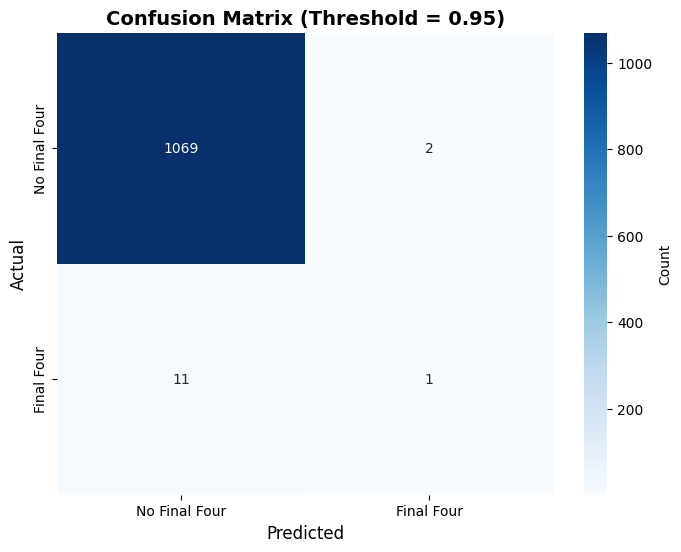

In [10]:
# Confusion matrix with adjusted threshold
threshold = 0.95
y_pred_adjusted = (y_pred_proba >= threshold).astype(int)

print("="*50)
print(f"CONFUSION MATRIX (Threshold = {threshold})")
print("="*50)

cm_adjusted = confusion_matrix(y_test, y_pred_adjusted)
print(cm_adjusted)

# Visualize
plt.figure(figsize=(8, 6))
sns.heatmap(cm_adjusted, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['No Final Four', 'Final Four'],
            yticklabels=['No Final Four', 'Final Four'],
            cbar_kws={'label': 'Count'})
plt.title(f'Confusion Matrix (Threshold = {threshold})', fontsize=14, fontweight='bold')
plt.ylabel('Actual', fontsize=12)
plt.xlabel('Predicted', fontsize=12)

# Add text annotations explaining each qu

In [11]:
print("="*50)
print(f"CLASSIFICATION REPORT (Threshold = {threshold})")
print("="*50)
print(classification_report(y_test, y_pred_adjusted))

CLASSIFICATION REPORT (Threshold = 0.95)
              precision    recall  f1-score   support

           0       0.99      1.00      0.99      1071
           1       0.33      0.08      0.13        12

    accuracy                           0.99      1083
   macro avg       0.66      0.54      0.56      1083
weighted avg       0.98      0.99      0.98      1083



### ROC-AUC Score

* Score is high because most teams are not Final-Four caliber

ROC-AUC Score: 0.9669


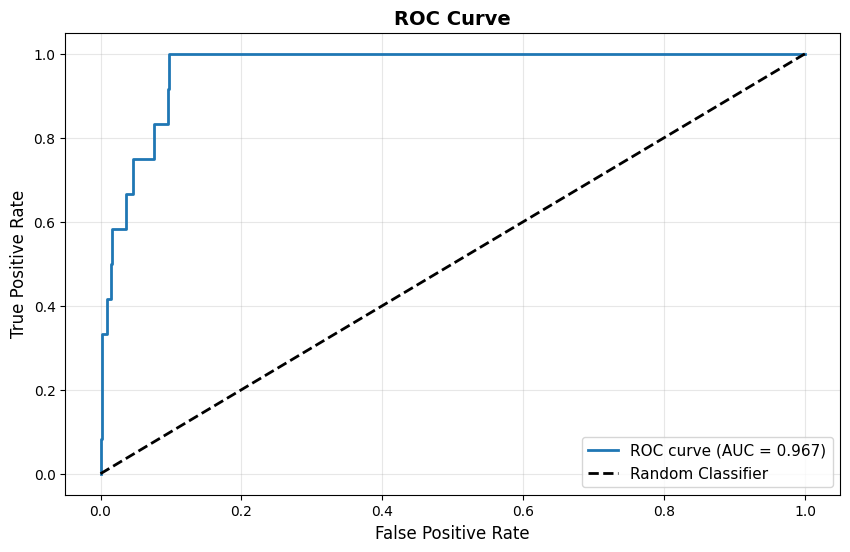

In [12]:
# ROC-AUC Score
roc_auc = roc_auc_score(y_test, y_pred_proba)
print(f"ROC-AUC Score: {roc_auc:.4f}")

# ROC Curve
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)

plt.figure(figsize=(10, 6))
plt.plot(fpr, tpr, linewidth=2, label=f'ROC curve (AUC = {roc_auc:.3f})')
plt.plot([0, 1], [0, 1], 'k--', linewidth=2, label='Random Classifier')
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('ROC Curve', fontsize=14, fontweight='bold')
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.show()

### Feature Importance

In [13]:
# Feature importance (coefficients)
feature_importance = pd.DataFrame({
    'feature': features,
    'coefficient': log_reg.coef_[0]
}).sort_values('coefficient', key=abs, ascending=False)

print("="*50)
print("FEATURE IMPORTANCE (Coefficients)")
print("="*50)
display(feature_importance.head(20))

FEATURE IMPORTANCE (Coefficients)


,feature,coefficient
2,adj_d,-2.743686
1,adj_o,2.294094
6,wab,-0.948758
7,ov_cur_sos,0.866644
0,barthag,0.628505
4,seed_filled,-0.565249
3,adj_t,-0.378907
5,elite_seed,-0.212343


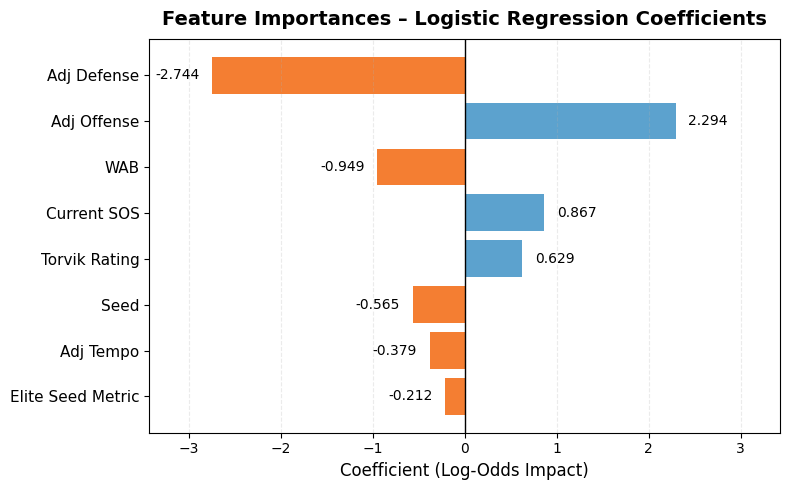

In [14]:
# lavel map for cleaner plot labels
label_map = {
    "barthag": "Torvik Rating",
    "seed_filled": "Seed",
    "adj_t": "Adj Tempo",
    "adj_d": "Adj Defense",
    "adj_o": "Adj Offense",
    "elite_seed": "Elite Seed Metric",
    "ov_cur_sos": "Current SOS",
    "wab": "WAB"
}

df = feature_importance.copy()

# Add clean labels (fallback to original feature if unmapped)
df["clean_label"] = df["feature"].map(label_map).fillna(df["feature"])

# Sort by absolute coefficient magnitude (smallest -> largest)
df = df.sort_values("coefficient", key=np.abs, ascending=True)

plt.figure(figsize=(8, 5))
y_pos = np.arange(len(df))

# Color by sign: blue = positive, orange = negative
colors = [
    plt.cm.Blues(0.6) if coef >= 0 else plt.cm.Oranges(0.6)
    for coef in df["coefficient"]
]

bars = plt.barh(
    y_pos,
    df["coefficient"],
    color=colors,
    alpha=0.9
)

plt.yticks(y_pos, df["clean_label"], fontsize=11)
plt.xlabel("Coefficient (Log-Odds Impact)", fontsize=12)
plt.title("Feature Importances – Logistic Regression Coefficients",
          fontsize=14, fontweight="bold", pad=10)

# Grid only on x-axis
plt.grid(axis="x", linestyle="--", alpha=0.25)

max_val = np.max(np.abs(df["coefficient"]))

# Add a bit of padding on both right/left sides
plt.xlim(-max_val * 1.25, max_val * 1.25)

for bar, val in zip(bars, df["coefficient"]):

    # position text slightly outside the bar but within axis limits
    if val >= 0:
        x_text = min(val + 0.05 * max_val, max_val * 1.15)
        ha = "left"
    else:
        x_text = max(val - 0.05 * max_val, -max_val * 1.15)
        ha = "right"

    plt.text(
        x_text,
        bar.get_y() + bar.get_height() / 2,
        f"{val:.3f}",
        va="center",
        ha=ha,
        fontsize=10
    )

# Zero line for interpretation
plt.axvline(0, color="black", linewidth=1)

plt.tight_layout()
plt.show()